In [13]:
import numpy as np
import matplotlib.pyplot as plt

def f(t,y):
    return y**2 - 10
 
def fprime(y):
    return 2*y
    
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # Initial guess
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)     
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new  # Converged
        y_next = y_new
    return y_next

# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        # Single step with h
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        # Error estimation
        error = abs(y_full - y_half_2)
        # Adjust step size
        if error > tol:
            h /= 2  # Decrease step size
            continue  # Retry the step with smaller h
        elif error < tol / 2:
            h *= 2  # Increase step size for efficiency
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

In [14]:
# Example Setup to run the adaptive solver:
y0 = 3.0       # Initial condition
t0 = 0.0       # Start time
tf = 2.0       # End time
h_init = 0.1   # Initial step size

# Running the simulation
t_vals, y_vals = backward_euler_adaptive(f, y0, t0, tf, h_init)

# Print results
for time, val in zip(t_vals, y_vals):
    print(f"t: {time:.4f} | y: {val:.4f}")

t: 0.0000 | y: 3.0000
t: 0.0008 | y: 2.9992
t: 0.0016 | y: 2.9984
t: 0.0023 | y: 2.9976
t: 0.0031 | y: 2.9968
t: 0.0039 | y: 2.9960
t: 0.0047 | y: 2.9952
t: 0.0055 | y: 2.9944
t: 0.0062 | y: 2.9936
t: 0.0070 | y: 2.9928
t: 0.0078 | y: 2.9920
t: 0.0086 | y: 2.9912
t: 0.0094 | y: 2.9903
t: 0.0102 | y: 2.9895
t: 0.0109 | y: 2.9887
t: 0.0117 | y: 2.9878
t: 0.0125 | y: 2.9870
t: 0.0133 | y: 2.9862
t: 0.0141 | y: 2.9853
t: 0.0148 | y: 2.9849
t: 0.0156 | y: 2.9845
t: 0.0164 | y: 2.9840
t: 0.0172 | y: 2.9836
t: 0.0180 | y: 2.9832
t: 0.0188 | y: 2.9827
t: 0.0195 | y: 2.9823
t: 0.0203 | y: 2.9819
t: 0.0211 | y: 2.9814
t: 0.0219 | y: 2.9810
t: 0.0227 | y: 2.9806
t: 0.0234 | y: 2.9801
t: 0.0242 | y: 2.9797
t: 0.0250 | y: 2.9793
t: 0.0258 | y: 2.9788
t: 0.0266 | y: 2.9784
t: 0.0273 | y: 2.9779
t: 0.0281 | y: 2.9775
t: 0.0289 | y: 2.9770
t: 0.0297 | y: 2.9766
t: 0.0305 | y: 2.9762
t: 0.0313 | y: 2.9757
t: 0.0320 | y: 2.9753
t: 0.0328 | y: 2.9748
t: 0.0336 | y: 2.9744
t: 0.0344 | y: 2.9739
t: 0.0352 

t: 0.9164 | y: -1.0676
t: 0.9168 | y: -1.0710
t: 0.9172 | y: -1.0745
t: 0.9176 | y: -1.0779
t: 0.9180 | y: -1.0814
t: 0.9184 | y: -1.0848
t: 0.9187 | y: -1.0883
t: 0.9191 | y: -1.0917
t: 0.9195 | y: -1.0952
t: 0.9199 | y: -1.0986
t: 0.9203 | y: -1.1020
t: 0.9207 | y: -1.1055
t: 0.9211 | y: -1.1089
t: 0.9215 | y: -1.1123
t: 0.9219 | y: -1.1157
t: 0.9223 | y: -1.1192
t: 0.9227 | y: -1.1226
t: 0.9230 | y: -1.1260
t: 0.9234 | y: -1.1294
t: 0.9238 | y: -1.1328
t: 0.9242 | y: -1.1362
t: 0.9246 | y: -1.1396
t: 0.9250 | y: -1.1430
t: 0.9254 | y: -1.1464
t: 0.9258 | y: -1.1498
t: 0.9262 | y: -1.1532
t: 0.9266 | y: -1.1565
t: 0.9270 | y: -1.1599
t: 0.9273 | y: -1.1633
t: 0.9277 | y: -1.1667
t: 0.9281 | y: -1.1701
t: 0.9285 | y: -1.1734
t: 0.9289 | y: -1.1768
t: 0.9293 | y: -1.1802
t: 0.9297 | y: -1.1835
t: 0.9301 | y: -1.1869
t: 0.9305 | y: -1.1902
t: 0.9309 | y: -1.1936
t: 0.9312 | y: -1.1969
t: 0.9316 | y: -1.2003
t: 0.9320 | y: -1.2036
t: 0.9324 | y: -1.2069
t: 0.9328 | y: -1.2103
t: 0.9332 |

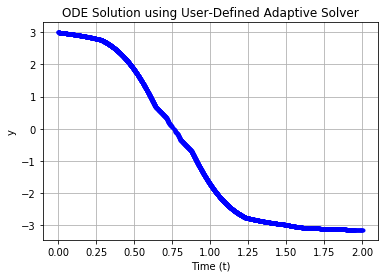

In [17]:
plt.plot(t_vals, y_vals, 'b-o', markersize=3)
plt.title('ODE Solution using User-Defined Adaptive Solver')
plt.xlabel('Time (t)')
plt.ylabel('y')
plt.grid(True)
plt.show()

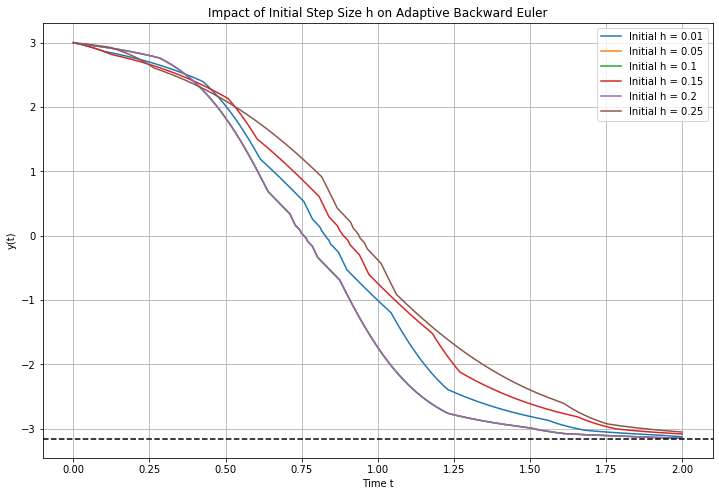

In [19]:
h_list = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]

plt.figure(figsize=(12, 8))

for h_init in h_list:
    t_res, y_res = backward_euler_adaptive(f, y0, t0, tf, h_init)
    plt.plot(t_res, y_res, label=f'Initial h = {h_init}')

plt.axhline(-np.sqrt(10), color='black', linestyle='--')
plt.title('Impact of Initial Step Size h on Adaptive Backward Euler')
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()

Used AI tool, Google Gemini to check over all my code and logic to make sure this made sense.